In [ ]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# printing the stopwords in English
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
# Load datasets
true_news = pd.read_csv('True.csv')
fake_news = pd.read_csv('Fake.csv')



In [ ]:
# Add labels
true_news['label'] = 0
fake_news['label'] = 1



In [ ]:
# Combine datasets
news_dataset = pd.concat([true_news, fake_news], axis=0)


In [ ]:
# Shuffle dataset
news_dataset = news_dataset.sample(frac=1, random_state=42)



In [ ]:
# Reset index
news_dataset.reset_index(drop=True, inplace=True)


In [ ]:
# Display first rows
print(news_dataset.head())

                                               title  \
0   BREAKING: GOP Chairman Grassley Has Had Enoug...   
1   Failed GOP Candidates Remembered In Hilarious...   
2   Mike Pence’s New DC Neighbors Are HILARIOUSLY...   
3  California AG pledges to defend birth control ...   
4  AZ RANCHERS Living On US-Mexico Border Destroy...   

                                                text       subject  \
0  Donald Trump s White House is in chaos, and th...          News   
1  Now that Donald Trump is the presumptive GOP n...          News   
2  Mike Pence is a huge homophobe. He supports ex...          News   
3  SAN FRANCISCO (Reuters) - California Attorney ...  politicsNews   
4  Twisted reasoning is all that comes from Pelos...      politics   

               date  label  
0     July 21, 2017      1  
1       May 7, 2016      1  
2  December 3, 2016      1  
3  October 6, 2017       0  
4      Apr 25, 2017      1  


In [ ]:
#Text Preprocessing
# Combine title and text
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')

port_stem = PorterStemmer() #initialize the stemmer
stop_words = set(nltk.corpus.stopwords.words('english')) #convert stopwords to a set outside the function for o(1) lookups

def stemming(content):
    review = re.sub('[^a-zA-Z]', ' ', str(content))
    review = review.lower()
    words = review.split()

    stemmed_words = [port_stem.stem(word) for word in words if word not in stop_words]


    return ' '.join(stemmed_words)

news_dataset['content'] = news_dataset['title']+ ' '+ news_dataset['text']

news_dataset['content'] = news_dataset['content'].apply(stemming)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Features and Labels
X = news_dataset['content']
Y = news_dataset['label']

In [ ]:
#TF-IDF Vectorization
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [ ]:
#Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [ ]:
#Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#Accuracy
# Training Accuracy

train_prediction = model.predict(X_train)

train_accuracy = accuracy_score(Y_train, train_prediction)

print("Training Accuracy:", train_accuracy)

# Testing Accuracy

test_prediction = model.predict(X_test)

test_accuracy = accuracy_score(Y_test, test_prediction)

print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9915641182693914
Testing Accuracy: 0.9865256124721603


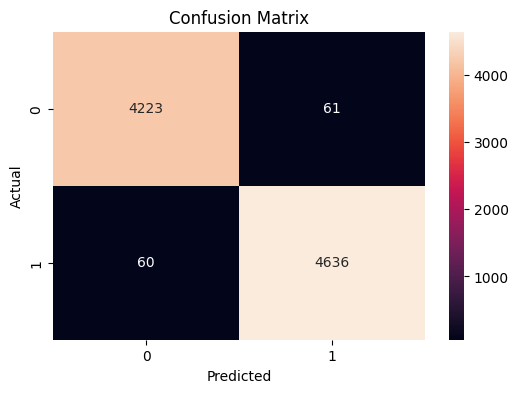

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, test_prediction)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

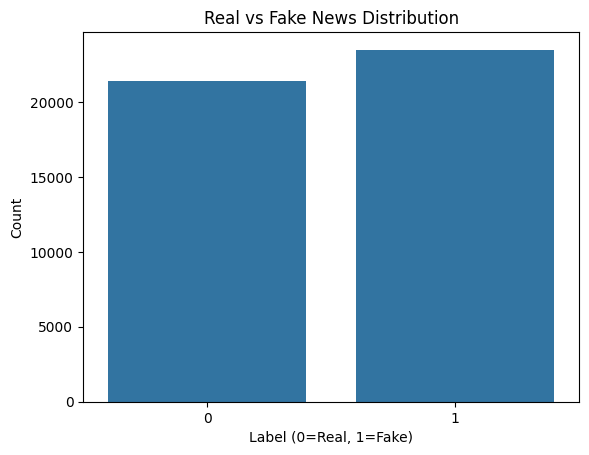

In [ ]:
#class Distribution(Shows how many Real vs Fake news articles are in the dataset.)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=news_dataset)
plt.title('Real vs Fake News Distribution')
plt.xlabel('Label (0=Real, 1=Fake)')
plt.ylabel('Count')
plt.show()

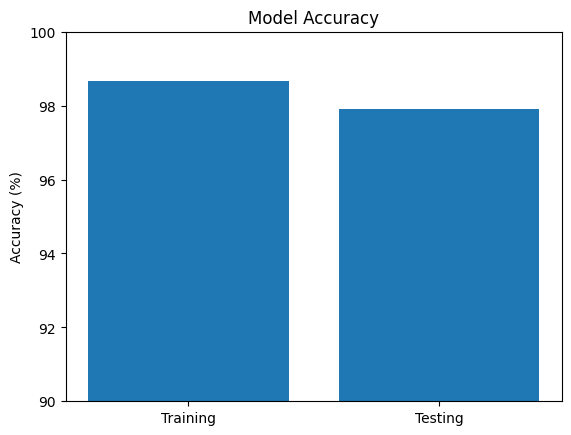

In [ ]:
#Accuracy Comparison(Useful for showing Training vs Testing Accuracy.)
#Model Accuracy(Comparison of training and testing accuracy.)
import matplotlib.pyplot as plt

labels = ['Training', 'Testing']
accuracy = [98.66, 97.91]

plt.bar(labels, accuracy)
plt.title('Model Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(90,100)
plt.show()

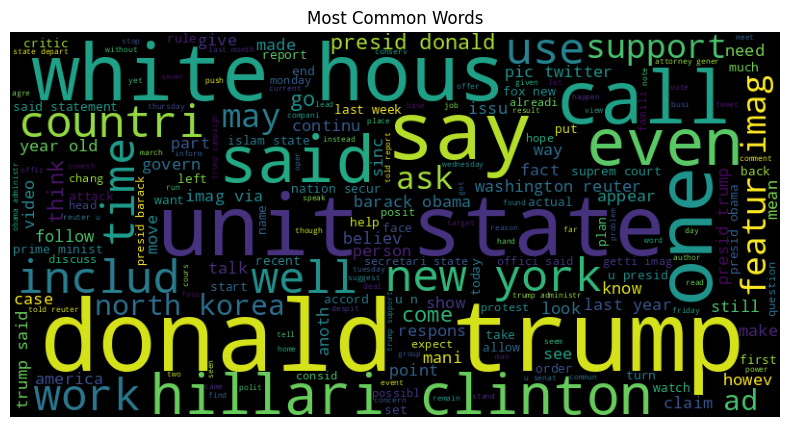

In [ ]:
#Word Cloud (Shows the most common words in news articles.)
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(news_dataset['content'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Most Common Words')
plt.show()

In [ ]:
#Predictive System
news = X_test[0]

prediction = model.predict(news)

if prediction[0] == 0:
    print("Real News")
else:
    print("Fake News")

Fake News


In [ ]:
#prediction for user input
user_news = input("Enter News Text: ")

user_news = stemming(user_news)

user_news_vector = vectorizer.transform([user_news])

prediction = model.predict(user_news_vector)

if prediction[0] == 0:
    print("📰 Real News")
else:
    print("🚨 Fake News")

Enter News Text: the government starts a new policy for jobless people
🚨 Fake News


In [ ]:
import pickle

# Save trained model
pickle.dump(model, open("fake_news_model.pkl", "wb"))

# Save vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Files Saved Successfully")

Files Saved Successfully


In [ ]:
from google.colab import files

files.download("fake_news_model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>